In [34]:

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [35]:

dataset_path = "/content/UCI HAR Dataset"

X_train = np.loadtxt(os.path.join(dataset_path, "train", "X_train.txt"))
y_train = np.loadtxt(os.path.join(dataset_path, "train", "y_train.txt")).astype(int)

X_test = np.loadtxt(os.path.join(dataset_path, "test", "X_test.txt"))
y_test = np.loadtxt(os.path.join(dataset_path, "test", "y_test.txt")).astype(int)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)


In [36]:

accuracies = []

for i in range(50):
    kmeans = KMeans(n_clusters=6, n_init=1, random_state=i)
    train_clusters = kmeans.fit_predict(X_train)
    test_clusters = kmeans.predict(X_test)

    cluster_to_label = {}

    for cluster in range(6):
        labels = y_train[train_clusters == cluster]

        if len(labels) > 0:
            values, counts = np.unique(labels, return_counts=True)
            cluster_to_label[cluster] = values[np.argmax(counts)]

    predicted = np.array([
        cluster_to_label.get(cluster, 1)
        for cluster in test_clusters
    ])

    accuracy = accuracy_score(y_test, predicted)
    accuracies.append(accuracy)

print("Average accuracy:", np.mean(accuracies) * 100, "%")
print("Best accuracy:", np.max(accuracies) * 100, "%")
print("Worst accuracy:", np.min(accuracies) * 100, "%")


Average accuracy: 60.93722429589413 %
Best accuracy: 69.29080420766881 %
Worst accuracy: 49.4740413980319 %


Best trial: 37
Test accuracy: 69.29080420766881 %

Confusion Matrix:
[[369  66  61   0   0   0]
 [ 91 352  28   0   0   0]
 [102  56 262   0   0   0]
 [  0   6   0   0 485   0]
 [  0   6   0   0 526   0]
 [  0   4   0   0   0 533]]

Classification Report:
              precision    recall  f1-score   support

           1       0.66      0.74      0.70       496
           2       0.72      0.75      0.73       471
           3       0.75      0.62      0.68       420
           4       0.00      0.00      0.00       491
           5       0.52      0.99      0.68       532
           6       1.00      0.99      1.00       537

    accuracy                           0.69      2947
   macro avg       0.61      0.68      0.63      2947
weighted avg       0.61      0.69      0.64      2947



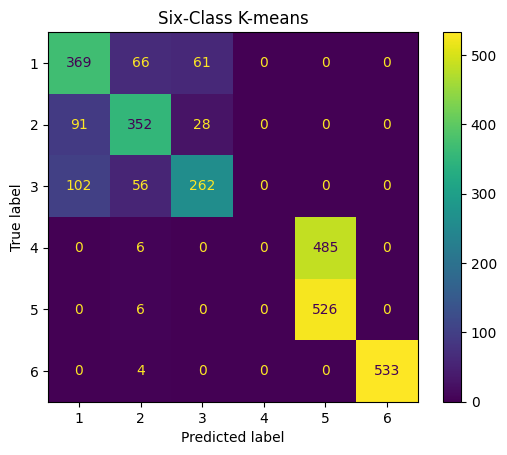

In [37]:

best_trial = int(np.argmax(accuracies))

kmeans = KMeans(n_clusters=6, n_init=1, random_state=best_trial)
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

cluster_to_label = {}

for cluster in range(6):
    labels = y_train[train_clusters == cluster]

    if len(labels) > 0:
        values, counts = np.unique(labels, return_counts=True)
        cluster_to_label[cluster] = values[np.argmax(counts)]

kmeans_pred = np.array([
    cluster_to_label.get(cluster, 1)
    for cluster in test_clusters
])

print("Best trial:", best_trial)
print("Test accuracy:", accuracy_score(y_test, kmeans_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, kmeans_pred, labels=[1, 2, 3, 4, 5, 6]))

print("\nClassification Report:")
print(classification_report(
    y_test, kmeans_pred,
    labels=[1, 2, 3, 4, 5, 6],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test, kmeans_pred,
    labels=[1, 2, 3, 4, 5, 6]
)
plt.title("Six-Class K-means")
plt.show()


In [38]:

y_train_binary = np.where(y_train <= 3, 1, 0)
y_test_binary = np.where(y_test <= 3, 1, 0)

kmeans_binary = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)

train_clusters_binary = kmeans_binary.fit_predict(X_train)
test_clusters_binary = kmeans_binary.predict(X_test)

cluster_to_label_binary = {}

for cluster in range(2):
    labels = y_train_binary[train_clusters_binary == cluster]

    if len(labels) > 0:
        values, counts = np.unique(labels, return_counts=True)
        cluster_to_label_binary[cluster] = values[np.argmax(counts)]

binary_pred = np.array([
    cluster_to_label_binary.get(cluster, 0)
    for cluster in test_clusters_binary
])

print("Binary K-means accuracy:",
      accuracy_score(y_test_binary, binary_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, binary_pred, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(
    y_test_binary, binary_pred,
    labels=[0, 1],
    target_names=["Sedentary", "Motion"],
    zero_division=0
))


Binary K-means accuracy: 99.8982015609094 %

Confusion Matrix:
[[1557    3]
 [   0 1387]]

Classification Report:
              precision    recall  f1-score   support

   Sedentary       1.00      1.00      1.00      1560
      Motion       1.00      1.00      1.00      1387

    accuracy                           1.00      2947
   macro avg       1.00      1.00      1.00      2947
weighted avg       1.00      1.00      1.00      2947



In [39]:

base_train = []
base_test = []

for activity in range(1, 7):
    y_binary_train = np.where(y_train == activity, 1, 0)

    svm = SVC(kernel="linear")
    svm.fit(X_train, y_binary_train)

    train_output = svm.decision_function(X_train)
    test_output = svm.decision_function(X_test)

    base_train.append(train_output)
    base_test.append(test_output)

base_train = np.array(base_train).T
base_test = np.array(base_test).T

print("Base training output shape:", base_train.shape)
print("Base testing output shape:", base_test.shape)


Base training output shape: (7352, 6)
Base testing output shape: (2947, 6)


Multi-layer SVM accuracy: 96.60671869697998 %

Confusion Matrix:
[[496   0   0   0   0   0]
 [ 20 450   1   0   0   0]
 [  2   5 413   0   0   0]
 [  0   1   0 434  56   0]
 [  1   0   0  14 517   0]
 [  0   0   0   0   0 537]]

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       496
           2       0.99      0.96      0.97       471
           3       1.00      0.98      0.99       420
           4       0.97      0.88      0.92       491
           5       0.90      0.97      0.94       532
           6       1.00      1.00      1.00       537

    accuracy                           0.97      2947
   macro avg       0.97      0.97      0.97      2947
weighted avg       0.97      0.97      0.97      2947



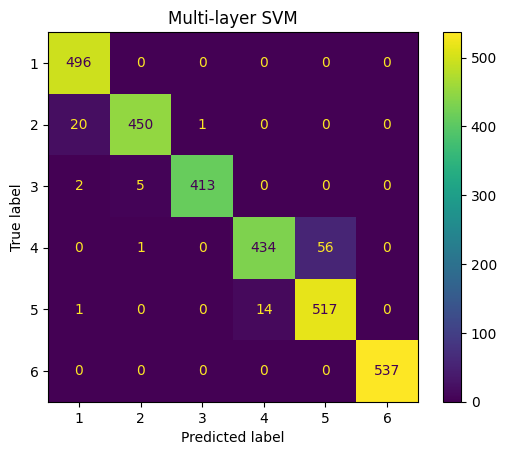

In [40]:

upper_svm = SVC(kernel="linear")
upper_svm.fit(base_train, y_train)

multilayer_pred = upper_svm.predict(base_test)

multilayer_accuracy = accuracy_score(y_test, multilayer_pred)

print("Multi-layer SVM accuracy:",
      multilayer_accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, multilayer_pred))

print("\nClassification Report:")
print(classification_report(y_test, multilayer_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, multilayer_pred)
plt.title("Multi-layer SVM")
plt.show()


In [41]:

# Replace selected_features with the actual 30 indices from Member 1.
# Do not invent the feature indices.

X_train_30 = X_train[:, selected_features]
X_test_30 = X_test[:, selected_features]

upper_train = np.hstack((X_train_30, base_train))
upper_test = np.hstack((X_test_30, base_test))

upper_svm = SVC(kernel="linear")
upper_svm.fit(upper_train, y_train)

multilayer_pred = upper_svm.predict(upper_test)

print("Multi-layer SVM accuracy:",
      accuracy_score(y_test, multilayer_pred) * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, multilayer_pred))

print("\nClassification Report:")
print(classification_report(y_test, multilayer_pred, zero_division=0))


NameError: name 'selected_features' is not defined

Hybrid prediction accuracy: 96.47098744485918 %

Confusion Matrix:
[[496   0   0   0   0   0]
 [ 19 451   1   0   0   0]
 [  3   5 412   0   0   0]
 [  0   4   0 427  59   1]
 [  1   0   0  11 520   0]
 [  0   0   0   0   0 537]]

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       496
           2       0.98      0.96      0.97       471
           3       1.00      0.98      0.99       420
           4       0.97      0.87      0.92       491
           5       0.90      0.98      0.94       532
           6       1.00      1.00      1.00       537

    accuracy                           0.96      2947
   macro avg       0.97      0.96      0.96      2947
weighted avg       0.97      0.96      0.96      2947



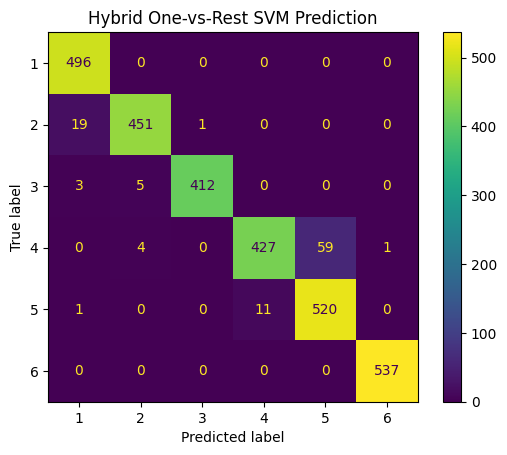

In [42]:

base_predictions = []

for activity in range(6):
    predictions = np.where(base_test[:, activity] > 0, 1, 0)
    base_predictions.append(predictions)

base_predictions = np.array(base_predictions).T

hybrid_pred = []

for i in range(len(X_test)):
    positive_votes = np.sum(base_predictions[i])

    if positive_votes == 1:
        hybrid_pred.append(np.argmax(base_predictions[i]) + 1)
    else:
        hybrid_pred.append(np.argmax(base_test[i]) + 1)

hybrid_pred = np.array(hybrid_pred)

hybrid_accuracy = accuracy_score(y_test, hybrid_pred)

print("Hybrid prediction accuracy:",
      hybrid_accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, hybrid_pred))

print("\nClassification Report:")
print(classification_report(y_test, hybrid_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, hybrid_pred)
plt.title("Hybrid One-vs-Rest SVM Prediction")
plt.show()


In [43]:

results = {
    "Six-Class K-means (Average)": np.mean(accuracies) * 100,
    "Six-Class K-means (Best)": np.max(accuracies) * 100,
    "Binary K-means": accuracy_score(y_test_binary, binary_pred) * 100,
    "Multi-layer SVM": multilayer_accuracy * 100,
    "Hybrid One-vs-Rest SVM": hybrid_accuracy * 100
}

print("MODEL ACCURACY COMPARISON")
print("-" * 40)

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.2f}%")


MODEL ACCURACY COMPARISON
----------------------------------------
Six-Class K-means (Average): 60.94%
Six-Class K-means (Best): 69.29%
Binary K-means: 99.90%
Multi-layer SVM: 96.61%
Hybrid One-vs-Rest SVM: 96.47%


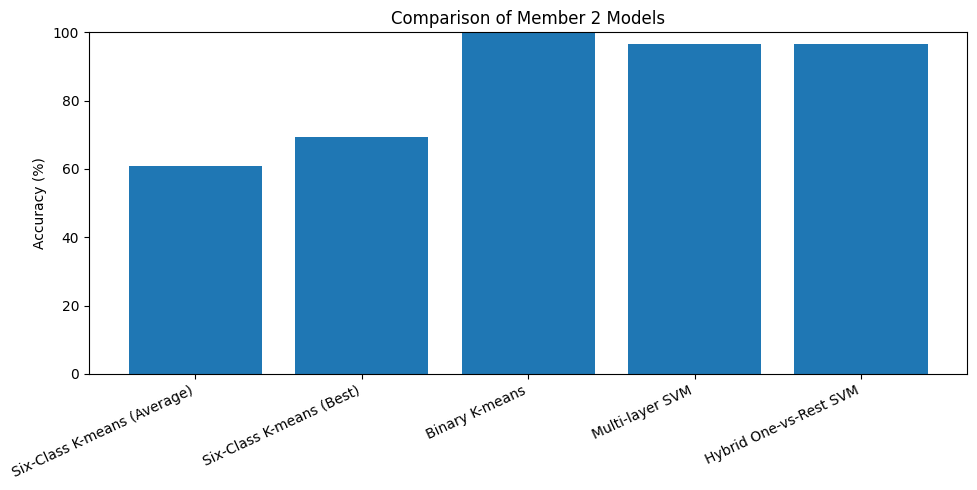

In [44]:

plt.figure(figsize=(10, 5))

plt.bar(results.keys(), results.values())

plt.ylabel("Accuracy (%)")
plt.title("Comparison of Member 2 Models")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()
